In [ ]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle

from google.colab import drive
drive.mount('/content/drive')

RUTA_BASE = "/content/drive/MyDrive/"

Mounted at /content/drive


Cargamos el dataset previo al preprocesado

In [ ]:
#Dataset Kaggle
df_prep = pd.read_csv(RUTA_BASE + "df_prep.csv")

In [ ]:
# Variables categóricas y numéricas
var_categoricas = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
var_numericas = ['age', 'avg_glucose_level', 'bmi']

Volvemos a reasignar las variables categóricas como "category"

In [ ]:
# Reconversión de variables categóricas
df_prep[var_categoricas] = df_prep[var_categoricas].astype("category")

No utilizaremos el id como variable predictora

In [ ]:
#Eliminamos la variable identificadora
df_prep = df_prep.drop(columns=["id"], errors="ignore")

# Train - test split

Llevamos a cabo un split estratificado del dataframe en proporcion 80 - 20, para mantener la proporción de Stroke en entrenamiento y test.

In [ ]:
from sklearn.model_selection import train_test_split

# Variables predictoras (todas menos stroke)
x = df_prep.drop(columns=["stroke"])

# Variable objetivo (stroke)
y = df_prep["stroke"]

# Split estratificado 80-20
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,      # 80% train, 20% test
    stratify=y,         # mantenemos la proporción de stroke
    random_state=24     # semilla aleatoria
)

#Copias independientes
x_train = x_train.copy()
x_test = x_test.copy()

Comprobamos que el split estratificado se ha llevado a cabo correctamente

In [ ]:
print("Distribución en dataset completo:")
print(len(df_prep)) #Número de observaciones totales
print(y.value_counts(normalize=True)*100)

print("\nDistribución en train:")
print(len(y_train)) #Número de observaciones para train
print(y_train.value_counts(normalize=True)*100)

print("\nDistribución en test:")
print(len(y_test))
print(y_test.value_counts(normalize=True)*100)

Distribución en dataset completo:
5110
stroke
No    95.127202
Sí     4.872798
Name: proportion, dtype: float64

Distribución en train:
4088
stroke
No    95.132094
Sí     4.867906
Name: proportion, dtype: float64

Distribución en test:
1022
stroke
No    95.107632
Sí     4.892368
Name: proportion, dtype: float64


# Imputación de valores faltantes

La imputación se ajusta únicamente sobre el conjunto de entrenamiento para evitar data leakage.

## Imputación variables numéricas


Imputamos el valor de bmi con su mediana en x_train y transformamos x_test con la misma mediana que hemos calculado en el train

In [ ]:
from sklearn.impute import SimpleImputer

# Creamos un imputador usando la mediana
imputer_num = SimpleImputer(strategy='median')

# Ajustamos solo en train
x_train[var_numericas] = imputer_num.fit_transform(x_train[var_numericas])

# Transformamos el test con la misma mediana que calculamos en train
x_test[var_numericas] = imputer_num.transform(x_test[var_numericas])


## Imputación de variables categóricas

Imputamos smoking_status usando la moda del train, asegurando así que no se "contamine" el test.

In [ ]:
# Creamos un imputador para variables categóricas a partir de la moda
imputer_cat = SimpleImputer(strategy='most_frequent')

# Ajustamos SOLO en X_train
x_train[var_categoricas] = imputer_cat.fit_transform(x_train[var_categoricas])

# Transformamos X_test con la misma moda que calculamos en X_train
x_test[var_categoricas] = imputer_cat.transform(x_test[var_categoricas])

Comprobamos que la imputación se ha llevado a cabo correctamente

In [ ]:
# Comprobamos que no quedan NaN en el train
x_train.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
# Comprobamos que no quedan NaN en el test
x_test.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


# Normalización de variables numéricas

Se apllica Min-Max Scaling par transformar las variables numéricas al rango [0,1]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador
scaler = MinMaxScaler()

# Ajustamos el escalador con X_train y transformamos
x_train[var_numericas] = scaler.fit_transform(x_train[var_numericas])

# Transformamos X_test con el mismo escalador (sin recalcular min/max)
x_test[var_numericas] = scaler.transform(x_test[var_numericas])

# Estadísticas descriptivas
print(x_train[var_numericas].describe().round(2))
print(x_test[var_numericas].describe().round(2))

           age  avg_glucose_level      bmi
count  4088.00            4088.00  4088.00
mean      0.53               0.23     0.20
std       0.28               0.21     0.09
min       0.00               0.00     0.00
25%       0.30               0.10     0.14
50%       0.55               0.17     0.19
75%       0.74               0.27     0.24
max       1.00               1.00     1.00
           age  avg_glucose_level      bmi
count  1022.00            1022.00  1022.00
mean      0.53               0.24     0.20
std       0.27               0.21     0.09
min       0.01               0.00    -0.02
25%       0.33               0.11     0.14
50%       0.54               0.17     0.19
75%       0.74               0.27     0.24
max       1.00               0.98     0.64


In [ ]:
#Dimensiones finales
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(4088, 10)
(4088,)
(1022, 10)
(1022,)


# Encoding de variables categóricas

Aplicamos One-Hot Encoding a todas las variables categóricas, convirtiendo cada categoría de la variable en una columna binaria. De esta forma, se preserva la información sin introducir un orden artificial.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Codificamos categóricas con One-Hot
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,      # para obtener DataFrame
    handle_unknown='ignore',  # ignora categorías nuevas en test
    drop='if_binary'          # genera solo una columna para variables binarias
)
x_train_one = pd.DataFrame( #codificación del conjunto de entrenamiento
    encoder.fit_transform(x_train[var_categoricas]),
    index=x_train.index,
    columns=encoder.get_feature_names_out(var_categoricas)
)

x_test_one = pd.DataFrame( # codificación del conjunto de test
    encoder.transform(x_test[var_categoricas]),
    index=x_test.index,
    columns=encoder.get_feature_names_out(var_categoricas)
)

# Concatenamos solo numéricas + One-Hot (sin columnas originales de texto)
x_train_encod = pd.concat([x_train[var_numericas], x_train_one], axis=1)
x_test_encod  = pd.concat([x_test[var_numericas], x_test_one], axis=1)

# Comprobamos que todo sea numérico
print(x_train_encod.dtypes.value_counts())  # deben ser solo float64


float64    16
Name: count, dtype: int64


Comprobamos que las variables se han codificado correctamente

In [ ]:
x_train_encod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4088 entries, 205 to 660
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         4088 non-null   float64
 1   avg_glucose_level           4088 non-null   float64
 2   bmi                         4088 non-null   float64
 3   gender_Mujer                4088 non-null   float64
 4   hypertension_Sí             4088 non-null   float64
 5   heart_disease_Sí            4088 non-null   float64
 6   ever_married_Sí             4088 non-null   float64
 7   work_type_Autónomo          4088 non-null   float64
 8   work_type_Empleado público  4088 non-null   float64
 9   work_type_Niño              4088 non-null   float64
 10  work_type_Nunca trabajó     4088 non-null   float64
 11  work_type_Sector privado    4088 non-null   float64
 12  residence_type_Urbano       4088 non-null   float64
 13  smoking_status_Exfumador    4088 non-

In [ ]:
x_test_encod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1022 entries, 1508 to 1819
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1022 non-null   float64
 1   avg_glucose_level           1022 non-null   float64
 2   bmi                         1022 non-null   float64
 3   gender_Mujer                1022 non-null   float64
 4   hypertension_Sí             1022 non-null   float64
 5   heart_disease_Sí            1022 non-null   float64
 6   ever_married_Sí             1022 non-null   float64
 7   work_type_Autónomo          1022 non-null   float64
 8   work_type_Empleado público  1022 non-null   float64
 9   work_type_Niño              1022 non-null   float64
 10  work_type_Nunca trabajó     1022 non-null   float64
 11  work_type_Sector privado    1022 non-null   float64
 12  residence_type_Urbano       1022 non-null   float64
 13  smoking_status_Exfumador    1022 no

# Gestión del desbalanceo de Stroke

La variable Stoke presenta un fuerte desbalanceo ente clases. Se generan tres escenarios:


1.   Dataset original desbalanceado
2.   Undersampling aleatorio
3.   Sobremuestreo mediante SMOTE



Guardamos un primer dataset en el que no se altera el desbalanceo de Stroke

In [ ]:
# Dataset desbalanceado
x_train_desbal = x_train_encod
y_train_desbal = y_train
x_test_final = x_test_encod
y_test_final = y_test

## *Undersampling*

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

#Reducción aleatoria de la clase mayoritaria
rus = RandomUnderSampler(random_state=24)
x_train_under, y_train_under = rus.fit_resample(x_train_encod, y_train)

#Distribución antes y después de Undersampling
print("Antes:", x_train_encod.shape, y_train.value_counts().to_dict())
print("Después:", x_train_under.shape, y_train_under.value_counts().to_dict())

Antes: (4088, 16) {'No': 3889, 'Sí': 199}
Después: (398, 16) {'No': 199, 'Sí': 199}


Comprobamos el rendimiento de Undersampling analizando algunas de las variables más significativas del dataset en x_train

In [ ]:
# Estadísticas de variables numéricas antes
print("Antes de Undersampling")
print(x_train_encod.describe().T[['mean','std','min','max']])

# Estadísticas de variables numéricas después
print("\nDespués de Undersampling")
print(pd.DataFrame(x_train_under, columns=x_train_encod.columns).describe().T[['mean','std','min','max']])

Antes de Undersampling
                                mean       std  min  max
age                         0.526095  0.276904  0.0  1.0
avg_glucose_level           0.234336  0.208112  0.0  1.0
bmi                         0.197177  0.090625  0.0  1.0
gender_Mujer                0.583659  0.493012  0.0  1.0
hypertension_Sí             0.099315  0.299121  0.0  1.0
heart_disease_Sí            0.054061  0.226165  0.0  1.0
ever_married_Sí             0.653865  0.475795  0.0  1.0
work_type_Autónomo          0.158757  0.365494  0.0  1.0
work_type_Empleado público  0.130382  0.336764  0.0  1.0
work_type_Niño              0.135274  0.342058  0.0  1.0
work_type_Nunca trabajó     0.004403  0.066218  0.0  1.0
work_type_Sector privado    0.571184  0.494967  0.0  1.0
residence_type_Urbano       0.508317  0.499992  0.0  1.0
smoking_status_Exfumador    0.171233  0.376758  0.0  1.0
smoking_status_Fumador      0.151908  0.358976  0.0  1.0
smoking_status_Nunca fumó   0.676859  0.467733  0.0  1.0

Después

Visualizamos las tres variables numéricas originales antes y después del Undersampling

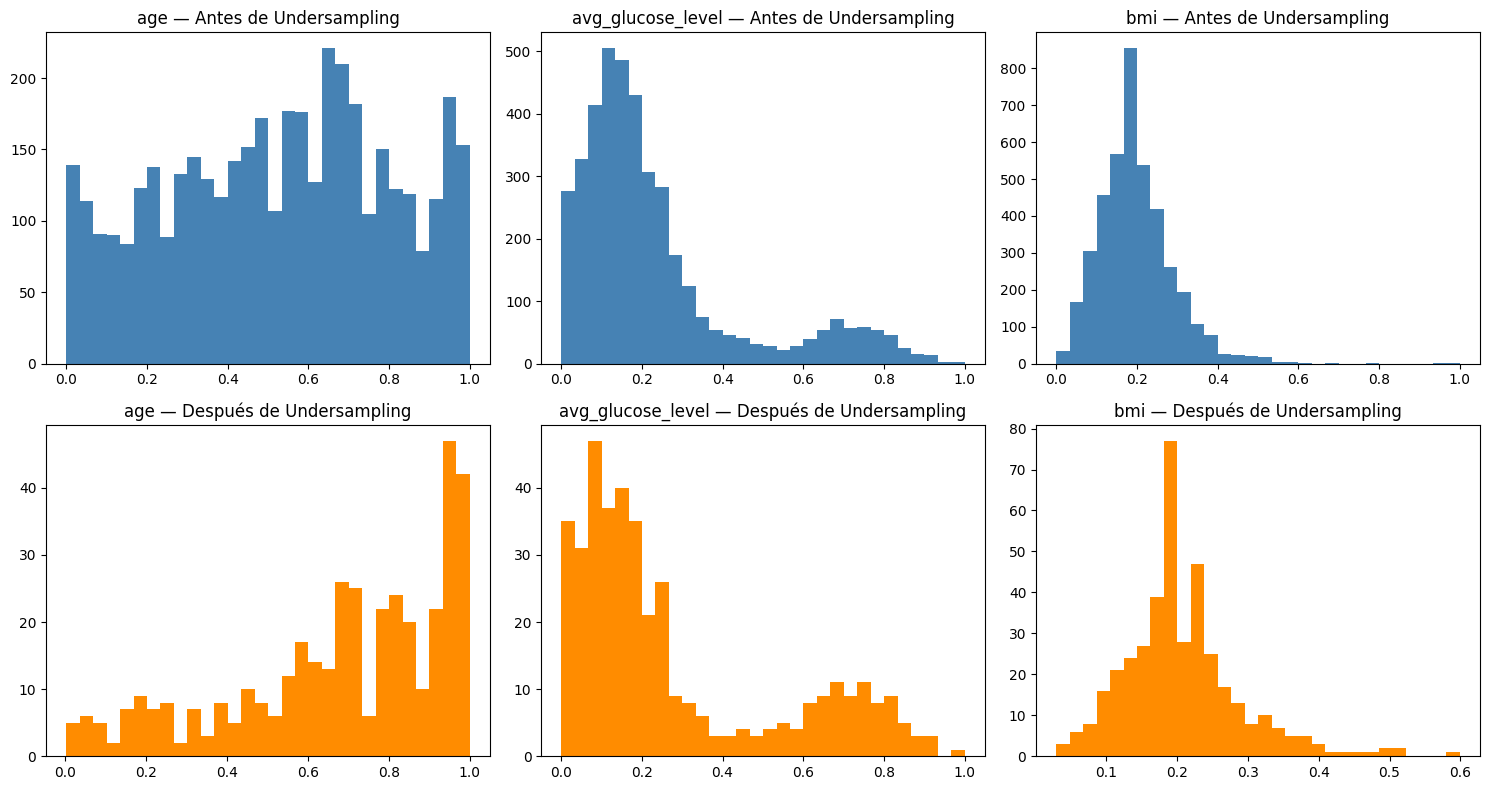

In [ ]:
x_train_under_df = pd.DataFrame(x_train_under, columns=x_train_encod.columns)

vars_plot = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(vars_plot):
    # Antes de undersampling
    axes[0, i].hist(x_train_encod[var], bins=30, color='steelblue')
    axes[0, i].set_title(f'{var} — Antes de Undersampling')

    # Después de undersampling
    axes[1, i].hist(x_train_under_df[var], bins=30, color='darkorange')
    axes[1, i].set_title(f'{var} — Después de Undersampling')

plt.tight_layout()
plt.show()

In [ ]:
# Datasets finales con undersampling
x_train_UNDER = x_train_under
y_train_UNDER = y_train_under

## SMOTE

Gestionamos el desbalanceo de Stroke con SMOTE. Aplicamos sobremuestreo sintético para equilibrar ambas clases.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=24)
x_train_bal, y_train_bal = smote.fit_resample(x_train_encod, y_train)

# Volvemos a convertir el array de numpy a una serie de pandas
y_train_bal = pd.Series(y_train_bal, name="stroke")

# Distribución antes y después
print("Antes de SMOTE:", x_train_encod.shape, y_train.shape)
print("Después de SMOTE:", x_train_bal.shape, y_train_bal.shape)

Antes de SMOTE: (4088, 16) (4088,)
Después de SMOTE: (7778, 16) (7778,)


In [ ]:
# Número de observaciones por clase
y_train_bal.value_counts()

,count
stroke,
Sí,3889
No,3889


Comprobamos la distribución de las variables antes y después del SMOTE

In [ ]:
# Estadísticas de variables numéricas antes
print("Antes de SMOTE")
print(x_train_encod.describe().T[['mean','std','min','max']])

# Estadísticas de variables numéricas después
print("\nDespués de SMOTE")
print(pd.DataFrame(x_train_bal, columns=x_train_encod.columns).describe().T[['mean','std','min','max']])

Antes de SMOTE
                                mean       std  min  max
age                         0.526095  0.276904  0.0  1.0
avg_glucose_level           0.234336  0.208112  0.0  1.0
bmi                         0.197177  0.090625  0.0  1.0
gender_Mujer                0.583659  0.493012  0.0  1.0
hypertension_Sí             0.099315  0.299121  0.0  1.0
heart_disease_Sí            0.054061  0.226165  0.0  1.0
ever_married_Sí             0.653865  0.475795  0.0  1.0
work_type_Autónomo          0.158757  0.365494  0.0  1.0
work_type_Empleado público  0.130382  0.336764  0.0  1.0
work_type_Niño              0.135274  0.342058  0.0  1.0
work_type_Nunca trabajó     0.004403  0.066218  0.0  1.0
work_type_Sector privado    0.571184  0.494967  0.0  1.0
residence_type_Urbano       0.508317  0.499992  0.0  1.0
smoking_status_Exfumador    0.171233  0.376758  0.0  1.0
smoking_status_Fumador      0.151908  0.358976  0.0  1.0
smoking_status_Nunca fumó   0.676859  0.467733  0.0  1.0

Después de SMOT

Visualizamos las tres variables numéricas originales antes y después del SMOTE

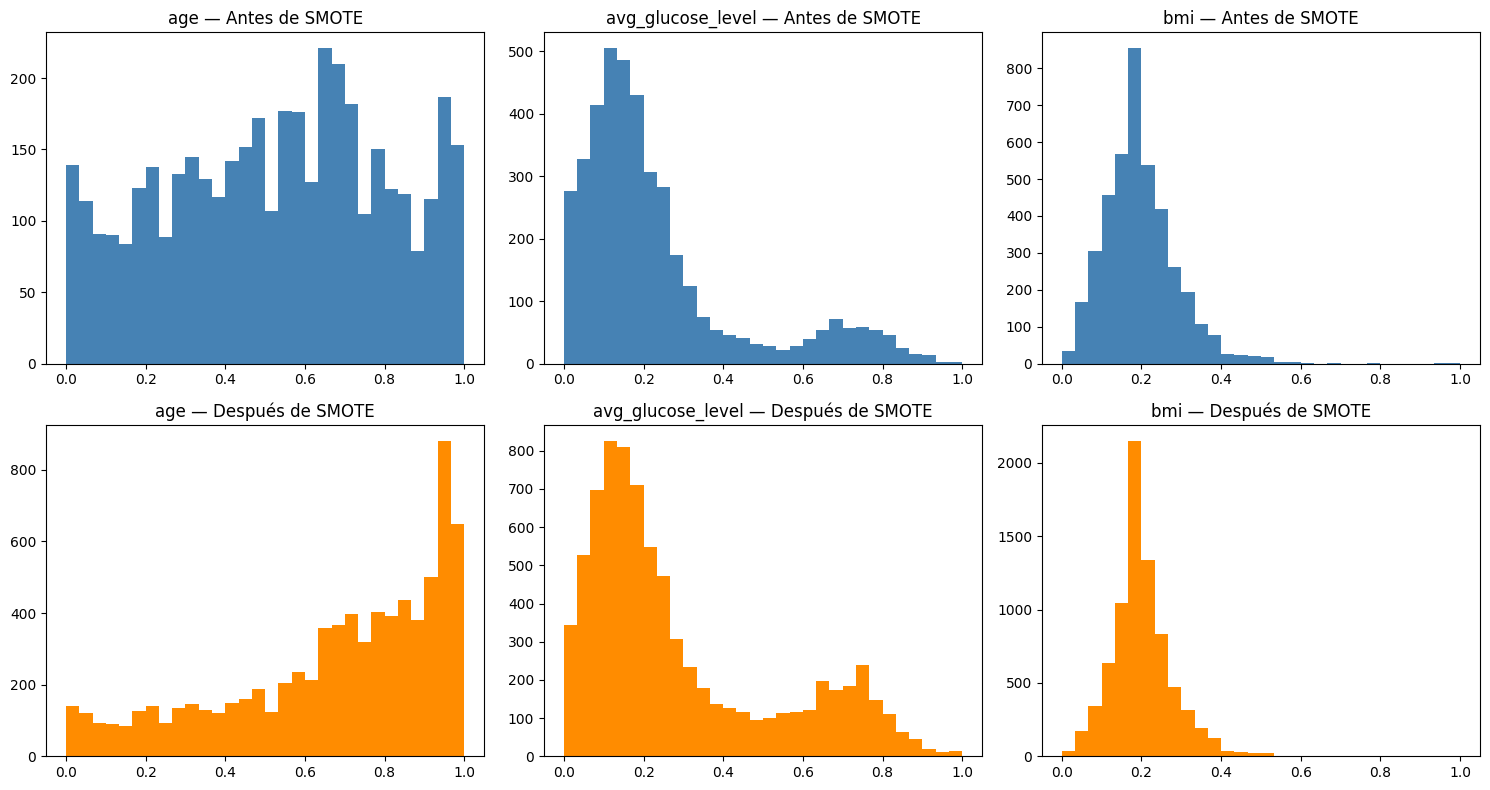

In [ ]:
#Fila 0 –> antes del SMOTE; Fila 1 -> después del SMOTE
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(var_numericas):
    # Antes de SMOTE
    axes[0, i].hist(x_train_encod[var], bins=30, color='steelblue')
    axes[0, i].set_title(f'{var} — Antes de SMOTE')

    # Después de SMOTE
    axes[1, i].hist(x_train_bal[var], bins=30, color='darkorange')
    axes[1, i].set_title(f'{var} — Después de SMOTE')

# Ajustamos espaciado para evitar solapamiento
plt.tight_layout()
plt.show()

In [ ]:
# Guardamos los dataset de entrenamiento finales con SMOTE
x_train_SMOTE = x_train_bal
y_train_SMOTE = y_train_bal
x_test_final = x_test_encod
y_test_final = y_test

Exportación final de datasets

In [ ]:
x_train_desbal.to_csv(RUTA_BASE + "x_train_desbal.csv", index=False)
x_train_UNDER.to_csv( RUTA_BASE + "x_train_UNDER.csv",  index=False)
x_train_SMOTE.to_csv( RUTA_BASE + "x_train_SMOTE.csv",  index=False)
x_test_final.to_csv(  RUTA_BASE + "x_test_final.csv",   index=False)

y_train_desbal.to_csv(RUTA_BASE + "y_train_desbal.csv", index=False)
y_train_UNDER.to_csv( RUTA_BASE + "y_train_UNDER.csv",  index=False)
y_train_SMOTE.to_csv( RUTA_BASE + "y_train_SMOTE.csv",  index=False)
y_test_final.to_csv(  RUTA_BASE + "y_test_final.csv",   index=False)
